## 自适应频域滤波器 + 多头VQ 软量化重构

In [1]:
import numpy as np
import os
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from typing import List, TypeVar, Any
Tensor = TypeVar('torch.tensor')

is_norm = True
new_min, new_max = -1, 1

input_dim = 15
hidden_dim = [64,128]
recon_dims = [64,32,15]
seq_len = 150
embedding_dim = 128
num_embeddings = 512

In [2]:
def data_to_model(data, sequence_length=120, step_size=25):
    data = data.float()
    sequences = []
    N = data.shape[0]
    
    for start_idx in range(0, N - sequence_length + 1, step_size):
        sequence = data[start_idx:start_idx + sequence_length]
        sequences.append(sequence)
    
    sequences = torch.stack(sequences)
    return sequences

def get_data(mode = '1-hover', phase = '2_5'):
    # 1-hover 2-forward 3-acc-x-axis-flag3-3000 5-motor03-flag4-085 6-motor03-flag3-200
    fmode = mode
    base_path = os.getcwd().split('\model')[0]

    sycn_raw_data = f'all_sycn_raw_data_mode{phase}.csv'
    sycn_err_data = f'all_sycn_err_data_mode{phase}.csv'
    sycn_sim_data = f'all_sycn_sim_data_mode{phase}.csv'

    sycn_raw_data_path = os.path.join(base_path, 'data', 'Dpro', fmode, sycn_raw_data)
    sycn_err_data_path = os.path.join(base_path, 'data', 'Dpro', fmode, sycn_err_data)
    sycn_sim_data_path = os.path.join(base_path, 'data', 'Dpro', fmode, sycn_sim_data)

    raw_data = pd.read_csv(sycn_raw_data_path).to_numpy()
    err_data = pd.read_csv(sycn_err_data_path).to_numpy()
    sim_data = pd.read_csv(sycn_sim_data_path).to_numpy()

    return raw_data, sim_data, err_data

def get_train_data(mode= ['1-hover', '2-forward', '1-hover'], phase = ['2_6', '2_5', '2_3']):
    fi_raw, fi_sim, fi_err = get_data(mode= mode[0], phase=phase[0])
    sim_data = np.vstack((fi_sim))
    raw_data = np.vstack((fi_raw))
    err_data = np.vstack((fi_err))
    for mo, ph in zip(mode[1:], phase[1:]):
        raw, sim, err = get_data(mode= mo, phase= ph)
        sim_data = np.vstack((sim_data, sim))
        raw_data = np.vstack((raw_data, raw))
        err_data = np.vstack((err_data, err))

    sim_data_split = np.split(sim_data, indices_or_sections=6, axis=1)
    raw_data_split = np.split(raw_data, indices_or_sections=6, axis=1)
    err_data_split = np.split(err_data, indices_or_sections=6, axis=1)

    sim_gyro, sim_acc, sim_mag, sim_pos, sim_vel, sim_eacc = sim_data_split[0], sim_data_split[1], sim_data_split[2], sim_data_split[3], sim_data_split[4], sim_data_split[5]
    raw_gyro, raw_acc, raw_mag, raw_pos, raw_vel, raw_eacc = raw_data_split[0], raw_data_split[1], raw_data_split[2], raw_data_split[3], raw_data_split[4], raw_data_split[5]
    err_gyro, err_acc, err_mag, err_pos, err_vel, err_eacc = err_data_split[0], err_data_split[1], err_data_split[2], err_data_split[3], err_data_split[4], err_data_split[5]

    sim_data_ = np.hstack((sim_acc, sim_gyro, sim_mag, sim_pos, sim_vel))
    raw_data_ = np.hstack((raw_acc, raw_gyro, raw_mag, raw_pos, raw_vel))
    err_data_ = np.hstack((err_acc, err_gyro, err_mag, err_pos, err_vel))

    return torch.tensor(sim_data_), torch.tensor(raw_data_), torch.tensor(err_data_)

def get_sensor_data(mode= ['1-hover', '2-forward', '1-hover'], phase = ['2_6', '2_5', '2_3'], label = 1, shuffle=False, ratio=1, sequence_length=80, step_size=1):
    sim, raw, err = get_train_data(mode, phase)

    if is_norm:
        sim_min_vals = torch.min(sim, dim=0)[0] 
        sim_max_vals = torch.max(sim, dim=0)[0]
        sim_normalized = ((sim - sim_min_vals) / (sim_max_vals - sim_min_vals)) * (new_max - new_min) + new_min

        raw_min_vals = torch.min(raw, dim=0)[0] 
        raw_max_vals = torch.max(raw, dim=0)[0]
        raw_normalized = ((raw - raw_min_vals) / (raw_max_vals - raw_min_vals)) * (new_max - new_min) + new_min

        err_min_vals = torch.min(err, dim=0)[0] 
        err_max_vals = torch.max(err, dim=0)[0]
        err_normalized = ((err - err_min_vals) / (err_max_vals - err_min_vals)) * (new_max - new_min) + new_min
    else:
        sim_min_vals, sim_max_vals, raw_min_vals, raw_max_vals, err_min_vals, err_max_vals = None, None, None, None, None, None
        sim_normalized, raw_normalized, err_normalized = sim, raw, err

    sim_2_model = data_to_model(data=sim_normalized, sequence_length=sequence_length, step_size=step_size)
    sim_2_model_label = torch.full((sim_2_model.size(0), 1), label, dtype=torch.long)

    raw_2_model = data_to_model(data=raw_normalized, sequence_length=sequence_length, step_size=step_size)
    raw_2_model_label = torch.full((raw_2_model.size(0), 1), label, dtype=torch.long)

    err_2_model = data_to_model(data=err_normalized, sequence_length=sequence_length, step_size=step_size)
    err_2_model_label = torch.full((err_2_model.size(0), 1), label, dtype=torch.long)

    if shuffle:
        torch.manual_seed(42)
        indices = torch.randperm(sim_2_model.size(0))

        sim_2_model = sim_2_model[indices]
        sim_2_model_label = sim_2_model_label[indices]
        raw_2_model = raw_2_model[indices]
        raw_2_model_label = raw_2_model_label[indices]
        err_2_model = err_2_model[indices]
        err_2_model_label = err_2_model_label[indices]

    sim_2_model = sim_2_model[:int(sim_2_model.size(0) * ratio)]
    sim_2_model_label = sim_2_model_label[:int(sim_2_model_label.size(0) * ratio)]
    raw_2_model = raw_2_model[:int(raw_2_model.size(0) * ratio)]
    raw_2_model_label = raw_2_model_label[:int(raw_2_model_label.size(0) * ratio)]
    err_2_model = err_2_model[:int(err_2_model.size(0) * ratio)]
    err_2_model_label = err_2_model_label[:int(err_2_model_label.size(0) * ratio)]

    return sim_2_model, sim_2_model_label, raw_2_model, raw_2_model_label, err_2_model, err_2_model_label, (raw_min_vals, raw_max_vals), (sim_min_vals, sim_max_vals), (err_min_vals, err_max_vals)

def normalize_data(x, data_min, data_max):
    return (x - data_min) / (data_max - data_min)

def denormalize_data(x, data_min, data_max):
    return ((x - new_min) / (new_max - new_min)) * (data_max - data_min) + data_min

# 1-hover 2-forward 3-acc-x-axis-flag3-3000 5-motor03-flag4-085 6-motor03-flag3-200
hover_2_model_sim, hover_2_model_sim_lables, hover_2_model_raw, hover_2_model_raw_lables, hover_2_model_err, hover_2_model_err_lables, (hover_raw_min_vals, hover_raw_max_vals), (hover_sim_min_vals, hover_sim_max_vals), (hover_err_min_vals, hover_err_max_vals) = get_sensor_data(mode= ['1-hover'], phase = ['2_6'], label = 1, shuffle=True, ratio=1, sequence_length=seq_len, step_size=4)
takeoff_2_model_sim, takeoff_2_model_sim_lables, takeoff_2_model_raw, takeoff_2_model_raw_lables, takeoff_2_model_err, takeoff_2_model_err_lables, (takeoff_raw_min_vals, takeoff_raw_max_vals), (takeoff_sim_min_vals, takeoff_sim_max_vals), (takeoff_err_min_vals, takeoff_err_max_vals) = get_sensor_data(mode= ['1-hover'], phase = ['2_3'], label = 2, shuffle=True, ratio=1, sequence_length=seq_len, step_size=4)

err_2_model = torch.cat((hover_2_model_err, takeoff_2_model_err), dim=0)
raw_2_model = torch.cat((hover_2_model_raw, takeoff_2_model_raw), dim=0)
sim_2_model = torch.cat((hover_2_model_sim, takeoff_2_model_sim), dim=0)
label_2_model = torch.cat((hover_2_model_raw_lables, takeoff_2_model_raw_lables), dim=0)

label_ana = {
    '1': (hover_raw_min_vals, hover_raw_max_vals, hover_sim_min_vals, hover_sim_max_vals, hover_err_min_vals, hover_err_max_vals),
    '2':(takeoff_raw_min_vals, takeoff_raw_max_vals, takeoff_sim_min_vals, takeoff_sim_max_vals, takeoff_err_min_vals, takeoff_err_max_vals)
}

print(f'hover_2_model_sim:{hover_2_model_sim.shape} takeoff_2_model_sim:{takeoff_2_model_sim.shape}')
print(f'err_2_model:{err_2_model.shape} label_2_model:{label_2_model.shape}')

dataset = TensorDataset(err_2_model, raw_2_model, sim_2_model, label_2_model)
batch_size = 4  # 每批次大小
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
sh = next(iter(dataloader))[0].shape
print(f'dataloader Len: {len(dataloader)} dataloader Shape: {sh}')


hover_2_model_sim:torch.Size([2510, 150, 15]) takeoff_2_model_sim:torch.Size([600, 150, 15])
err_2_model:torch.Size([3110, 150, 15]) label_2_model:torch.Size([3110, 1])
dataloader Len: 777 dataloader Shape: torch.Size([4, 150, 15])


In [3]:
from abc import abstractmethod

class BaseVAE(nn.Module):
    
    def __init__(self) -> None:
        super(BaseVAE, self).__init__()

    def encode(self, input: Tensor) -> List[Tensor]:
        raise NotImplementedError

    def decode(self, input: Tensor) -> Any:
        raise NotImplementedError

    def sample(self, batch_size:int, current_device: int, **kwargs) -> Tensor:
        raise NotImplementedError

    def generate(self, x: Tensor, **kwargs) -> Tensor:
        raise NotImplementedError

    @abstractmethod
    def forward(self, *inputs: Tensor) -> Tensor:
        pass

    @abstractmethod
    def loss_function(self, *inputs: Any, **kwargs) -> Tensor:
        pass

In [4]:
import pywt

class MultiHeadVectorQuantizer(nn.Module):
    def __init__(self, input_channel, num_embeddings, embedding_dim, heads, beta=0.25):
        super(MultiHeadVectorQuantizer, self).__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.beta = beta

        self.embeddings = nn.ModuleList([
            nn.Embedding(self.num_embeddings, self.embedding_dim) for _ in range(heads)
        ])

        for embedding in self.embeddings:
            embedding.weight.data.uniform_(-1 / self.num_embeddings, 1 / self.num_embeddings)

        self.low_freq_filter = nn.Conv1d(input_channel, input_channel, kernel_size=5, stride=1, padding=2)

        self.filter = nn.ModuleList([
            nn.Conv1d(input_channel, input_channel, kernel_size=11, stride=1, padding=11//2),
            nn.Conv1d(input_channel, input_channel, kernel_size=9, stride=1, padding=9//2),
            nn.Conv1d(input_channel, input_channel, kernel_size=7, stride=1, padding=7//2),
            nn.Conv1d(input_channel, input_channel, kernel_size=5, stride=1, padding=5//2),
            nn.Conv1d(input_channel, input_channel, kernel_size=3, stride=1, padding=3//2)
        ])

    def forward(self, latents):
        '''
        # 小波分解
        coeffs = [pywt.dwt(latents[:, :, i].detach().cpu().numpy(), self.wavelet) for i in range(latents.size(2))]
        approx = torch.stack([torch.tensor(c[0]) for c in coeffs], dim=-1)
        details = torch.stack([torch.tensor(c[1]) for c in coeffs], dim=-1)

        # 插值恢复时间步
        approx = approx.permute(0, 2, 1)  # [batch, time, latent_dim] -> [batch, latent_dim, time]
        details = details.permute(0, 2, 1)
        approx = torch.nn.functional.interpolate(approx, size=seq_len, mode='linear', align_corners=True)
        details = torch.nn.functional.interpolate(details, size=seq_len, mode='linear', align_corners=True)
        approx = approx.permute(0, 2, 1)  # [batch, latent_dim, time] -> [batch, time, latent_dim]
        details = details.permute(0, 2, 1)

        decomposed = [approx, details]

        if len(self.embeddings) > len(decomposed):
            num_extra = len(self.embeddings) - len(decomposed)
            decomposed.extend([decomposed[-1]] * num_extra)
        '''
        
        # 1. 对输入特征进行频率分离：低频和高频
        latents = latents.permute(0, 2, 1)  # [B, T, D] -> [B, D, T]

        # 2. 将低频和高频特征分别分配到不同的嵌入空间
        decomposed = [filter(latents).permute(0, 2, 1) for filter in self.filter]

        if len(self.embeddings) > len(decomposed):
            num_extra = len(self.embeddings) - len(decomposed)
            decomposed.extend([decomposed[-1]] * num_extra)

        quantized_outputs = []
        vq_losses = []

        for decompose, embedding in zip(decomposed, self.embeddings):
            decompose = decompose.to(latents.device)
            B, T, D = decompose.shape #  [batch_size, sequence_length, embedding_dim]
            flat_latents = decompose.reshape(-1, D) # [batch_size * sequence_length, embedding_dim]

            dist = torch.cdist(flat_latents, embedding.weight, p=2) ** 2
            soft_assignments = F.softmax(-dist, dim=1)
            quantized = torch.matmul(soft_assignments, embedding.weight).view(B, T, D) # [batch_size, sequence_length, embedding_dim]
            
            embedding_loss = F.mse_loss(quantized, decompose.detach())
            commitment_loss = F.mse_loss(quantized.detach(), decompose)
            vq_loss = self.beta * commitment_loss + embedding_loss
            
            vq_losses.append(vq_loss)

            # Add the residue back to the latents
            quantized = decompose + (quantized - decompose).detach() 
            quantized_outputs.append(quantized)
            
        quantized_latents = torch.cat(quantized_outputs, dim=2)  # [B, T, D * len(kernel_sizes)]
        total_vq_loss = torch.stack(vq_losses).sum()  

        return quantized_latents, total_vq_loss
    
    def orthogonality_loss(self):
        """
        正交性损失：约束嵌入空间的中心向量。
        """
        loss = 0
        for embedding in self.embeddings:
            w = embedding.weight  # [num_embeddings, embedding_dim]
            norm_w = F.normalize(w, p=2, dim=1)
            gram_matrix = torch.matmul(norm_w, norm_w.t())
            loss += torch.sum(torch.abs(gram_matrix - torch.eye(gram_matrix.size(0), device=gram_matrix.device)))
        return loss

class VQVAE(BaseVAE):
    def __init__(self,
                 in_channels: int,  
                 embedding_dim: int,
                 num_embeddings: int,
                 heads: int,
                 hidden_dims: List = None,
                 recon_dims: List = None,
                 beta: float = 0.25,
                 orthogonality_weight: float = 0.1,
                 **kwargs) -> None:
        super(VQVAE, self).__init__()

        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings
        self.beta = beta
        self.orthogonality_weight = orthogonality_weight

        if hidden_dims is None:
            hidden_dims = [128, 256]

        input_dim = in_channels 
        self.lstm_encoders = nn.ModuleList()
        for hidden_dim in hidden_dims:
            self.lstm_encoders.append(nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, batch_first=True))
            input_dim = hidden_dim 

        self.vq_layer = MultiHeadVectorQuantizer(input_channel=hidden_dims[-1],
                                                 num_embeddings=num_embeddings,
                                                 embedding_dim=embedding_dim,
                                                 heads=heads,
                                                 beta=beta)

        input_dim = embedding_dim * heads
        self.lstm_decoders = nn.ModuleList()
        for h_dim in recon_dims:
            self.lstm_decoders.append(nn.LSTM(input_dim, h_dim, batch_first=True))
            input_dim = h_dim

    def encode(self, input: Tensor) -> Tensor:
        x = input
        for lstm in self.lstm_encoders:
            x, _ = lstm(x)
        return x

    def decode(self, z: Tensor) -> Tensor:
        x = z
        for lstm in self.lstm_decoders:
            x, _ = lstm(x)
        return x

    def forward(self, input: Tensor, **kwargs) -> Tensor:
        encoding = self.encode(input)
        quantized_inputs, vq_loss = self.vq_layer(encoding)
        # orthogonality_loss = self.orthogonality_weight * self.vq_layer.orthogonality_loss()

        recon = self.decode(quantized_inputs)
        recon_loss = F.mse_loss(input, recon)
        w_loss = self.wasserstein_loss(input, recon)
        total_loss = recon_loss + vq_loss 
        loss = {'Loss':total_loss, 'Recon_Loss':recon_loss, 'VQ_Loss':vq_loss, 'W_Loss':w_loss}
        return recon, loss
    
    def wasserstein_loss(self, x, recon_x, std_weight=1):
        """
        计算 Wasserstein 损失（即 Earth Mover's Distance）
        :param x: 原始输入序列, 形状为 [batch_size, seq_len, input_dim]
        :param recon_x: 重建的序列, 形状为 [batch_size, seq_len, input_dim]
        :return: Wasserstein 损失
        """
        # 计算原始数据和重建数据的均值和标准差
        mean_x = torch.mean(x, dim=(0, 1))  # 计算原始数据的均值 [batch_size]
        std_x = torch.std(x, dim=(0, 1))    # 计算原始数据的标准差 [batch_size]

        mean_recon_x = torch.mean(recon_x, dim=(0, 1))  # 计算重建数据的均值 [batch_size]
        std_recon_x = torch.std(recon_x, dim=(0, 1))    # 计算重建数据的标准差 [batch_size]

        # 计算 Wasserstein 距离（均值差异 + 标准差差异）
        # Wasserstein 距离是均值差异和标准差差异的组合
        loss = torch.mean(torch.abs(mean_x - mean_recon_x) + std_weight * torch.abs(std_x - std_recon_x))
        
        return loss


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
'''
# print(device)
# print(torch.__version__)                # 查看pytorch安装的版本号
# print(torch.cuda.is_available())        # 查看cuda是否可用。True为可用，即是gpu版本pytorch
# print(torch.cuda.get_device_name(0))    # 返回GPU型号
# print(torch.cuda.device_count())        # 返回可以用的cuda（GPU）数量，0代表一个
# print(torch.version.cuda) 
'''

vae = VQVAE(in_channels=input_dim, 
            embedding_dim=embedding_dim, 
            num_embeddings=num_embeddings,
            heads=5,
            hidden_dims=hidden_dim,
            recon_dims=recon_dims).to(device)

optimizer = optim.Adam(vae.parameters(), lr=1e-3)
print(vae)

VQVAE(
  (lstm_encoders): ModuleList(
    (0): LSTM(15, 64, batch_first=True)
    (1): LSTM(64, 128, batch_first=True)
  )
  (vq_layer): MultiHeadVectorQuantizer(
    (embeddings): ModuleList(
      (0): Embedding(512, 128)
      (1): Embedding(512, 128)
      (2): Embedding(512, 128)
      (3): Embedding(512, 128)
      (4): Embedding(512, 128)
    )
    (low_freq_filter): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (filter): ModuleList(
      (0): Conv1d(128, 128, kernel_size=(11,), stride=(1,), padding=(5,))
      (1): Conv1d(128, 128, kernel_size=(9,), stride=(1,), padding=(4,))
      (2): Conv1d(128, 128, kernel_size=(7,), stride=(1,), padding=(3,))
      (3): Conv1d(128, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (4): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    )
  )
  (lstm_decoders): ModuleList(
    (0): LSTM(640, 64, batch_first=True)
    (1): LSTM(64, 32, batch_first=True)
    (2): LSTM(32, 15, batch_first=True)
  )
)


Epoch [1/250],               Total loss: 0.1617,               Recons loss: 0.1060,               VQ loss: 0.0557,               W loss: 0.3226
Epoch [2/250],               Total loss: 0.0856,               Recons loss: 0.0744,               VQ loss: 0.0111,               W loss: 0.2437
Epoch [3/250],               Total loss: 0.0740,               Recons loss: 0.0662,               VQ loss: 0.0078,               W loss: 0.2190
Epoch [4/250],               Total loss: 0.0632,               Recons loss: 0.0595,               VQ loss: 0.0036,               W loss: 0.2005
Epoch [5/250],               Total loss: 0.0570,               Recons loss: 0.0542,               VQ loss: 0.0027,               W loss: 0.1838
Epoch [6/250],               Total loss: 0.0536,               Recons loss: 0.0509,               VQ loss: 0.0027,               W loss: 0.1750
Epoch [7/250],               Total loss: 0.0509,               Recons loss: 0.0479,               VQ loss: 0.0030,               W loss:

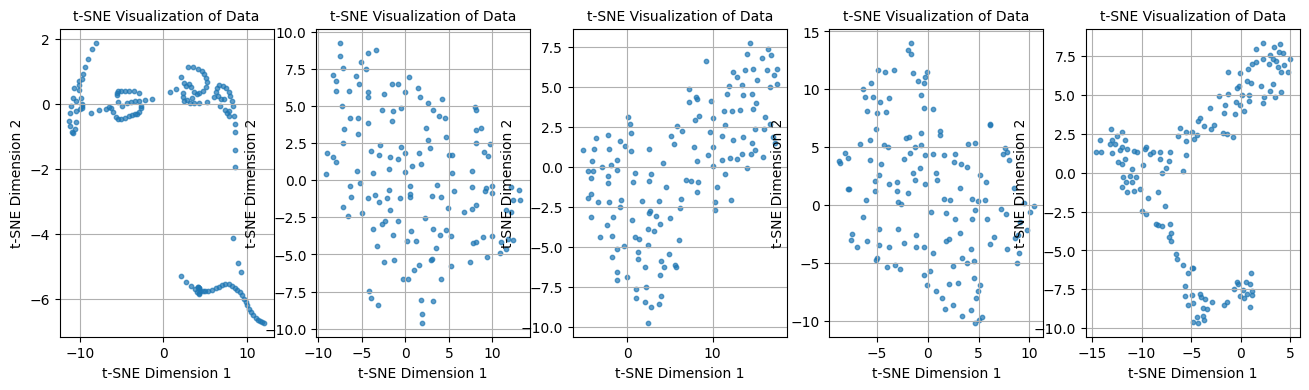

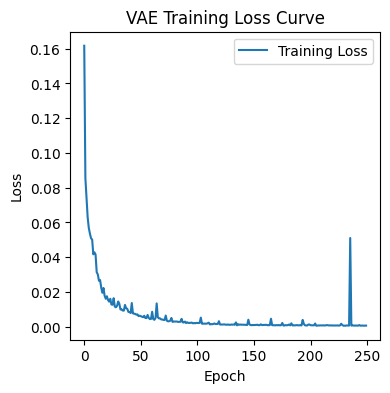

In [6]:
# 设置随机种子
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

def train_vae(dataloader, vae, num_epochs):
    vae.train()
    epoch_losses = []
    fig_cnt= 1
    plt.figure(figsize=(16, 4))
    for epoch in range(num_epochs):
        total_loss = 0.0
        total_recons_loss = 0
        total_vq_loss = 0
        total_w_loss = 0
        for err, _, _, _ in dataloader:
            optimizer.zero_grad()

            input_data = err  
            reconstructed, loss_dict = vae(input_data.to(device))
            loss = loss_dict['Loss']
            recons_loss = loss_dict['Recon_Loss']
            vq_loss = loss_dict['VQ_Loss']
            w_loss = loss_dict['W_Loss']
            
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            total_recons_loss += recons_loss.item()
            total_vq_loss += vq_loss.item()
            total_w_loss += w_loss.item()
        

        epoch_losses.append(total_loss / len(dataloader))
        print(f"Epoch [{epoch+1}/{num_epochs}], \
              Total loss: {total_loss / len(dataloader):.4f}, \
              Recons loss: {total_recons_loss / len(dataloader):.4f}, \
              VQ loss: {total_vq_loss / len(dataloader):.4f}, \
              W loss: {total_w_loss / len(dataloader):.4f}")

        if epoch % 50 == 0:
            data = reconstructed[0].cpu().detach().numpy()  
            tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
            data_2d = tsne.fit_transform(data)

            plt.subplot(1, num_epochs // 50, fig_cnt)
            plt.scatter(data_2d[:, 0], data_2d[:, 1], s=10, alpha=0.7, cmap='viridis')
            plt.title("t-SNE Visualization of Data", fontsize=10)
            plt.xlabel("t-SNE Dimension 1")
            plt.ylabel("t-SNE Dimension 2")
            plt.grid(True)
            fig_cnt += 1
    
    plt.figure(figsize=(4, 4))
    plt.plot(epoch_losses, label='Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('VAE Training Loss Curve')
    plt.legend()
    plt.show()

num_epochs = 250
train_vae(dataloader, vae, num_epochs)

In [7]:
look_dim = 11

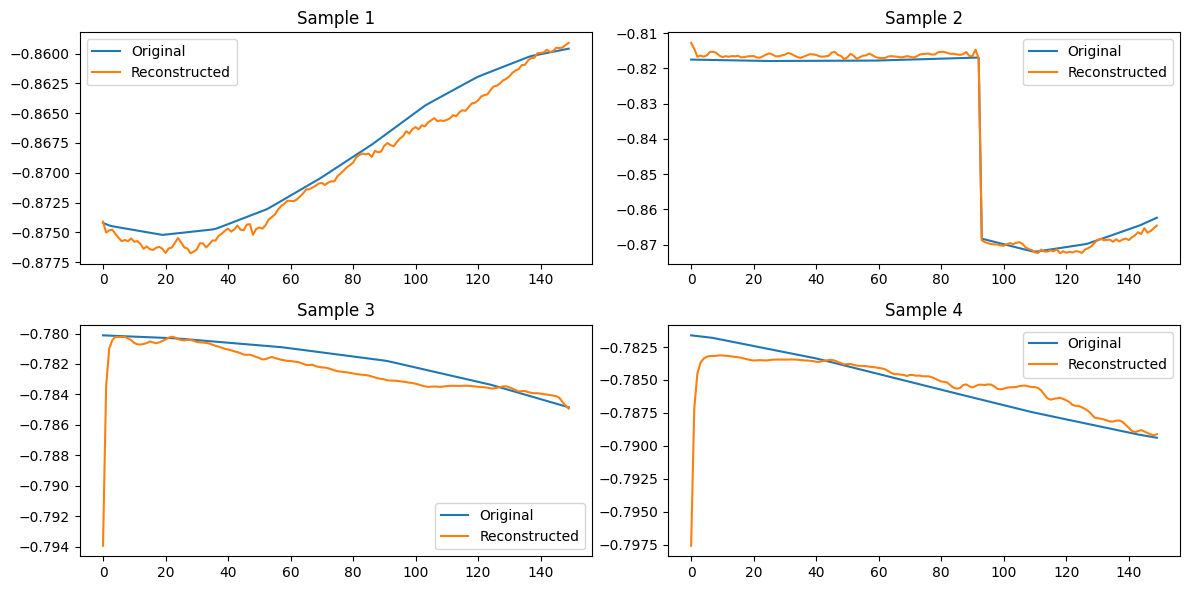

In [8]:
def test_vae(vae, test_loader, device):
    vae.eval()
    original_data = []
    reconstructed_data = []

    with torch.no_grad():
        for err, raw, sim, label in test_loader:
            err = err.to(device)
            label = label.to(device)
            recon_err, loss = vae(err)
            recon_err = recon_err.cpu()
            label = label.cpu()
            err = err.cpu()
            
            if is_norm:
                raw_min_vals = label_ana[str(label[0][0].numpy())][0]
                raw_max_vals = label_ana[str(label[0][0].numpy())][1]
                sim_min_vals = label_ana[str(label[0][0].numpy())][2]
                sim_max_vals = label_ana[str(label[0][0].numpy())][3]
                err_min_vals = label_ana[str(label[0][0].numpy())][4]
                err_max_vals = label_ana[str(label[0][0].numpy())][5]

                err_denorm = denormalize_data(err, err_min_vals, err_max_vals)
                recon_x_denorm = denormalize_data(recon_err, err_min_vals, err_max_vals) 

                raw_denorm = denormalize_data(raw, raw_min_vals, raw_max_vals)
                sim_denorm = denormalize_data(sim, sim_min_vals, sim_max_vals)

                sim_recon_denorm = sim_denorm - recon_x_denorm
            else:
                err_denorm = err
                recon_x_denorm = recon_err
                raw_denorm = raw
                sim_denorm = sim
                sim_recon_denorm = sim_denorm - recon_x_denorm
             
            original_data.append(raw_denorm.cpu())
            reconstructed_data.append(sim_recon_denorm.cpu())


    # 将数据拼接成单个张量
    original_data = torch.cat(original_data, dim=0)
    reconstructed_data = torch.cat(reconstructed_data, dim=0)

    plot_reconstruction(original_data, reconstructed_data)

def plot_reconstruction(original_data, reconstructed_data, dim=look_dim):
    plt.figure(figsize=(12, 6))
    seq_len = original_data.size(1)
    
    for i in range(4):
        plt.subplot(2, 2, i + 1)
        plt.plot(range(seq_len), original_data[i][:,dim].numpy(), label="Original")
        plt.plot(range(seq_len), reconstructed_data[i][:,dim].numpy(), label="Reconstructed")
        plt.legend()
        plt.title(f"Sample {i+1}")
    
    plt.tight_layout()
    plt.show()

test_vae(vae, dataloader, device)

Reconstruction Errors (averaged over batches):
Average RMSE: 0.0304
Average MAE: 0.0105
Average R²: 0.9690


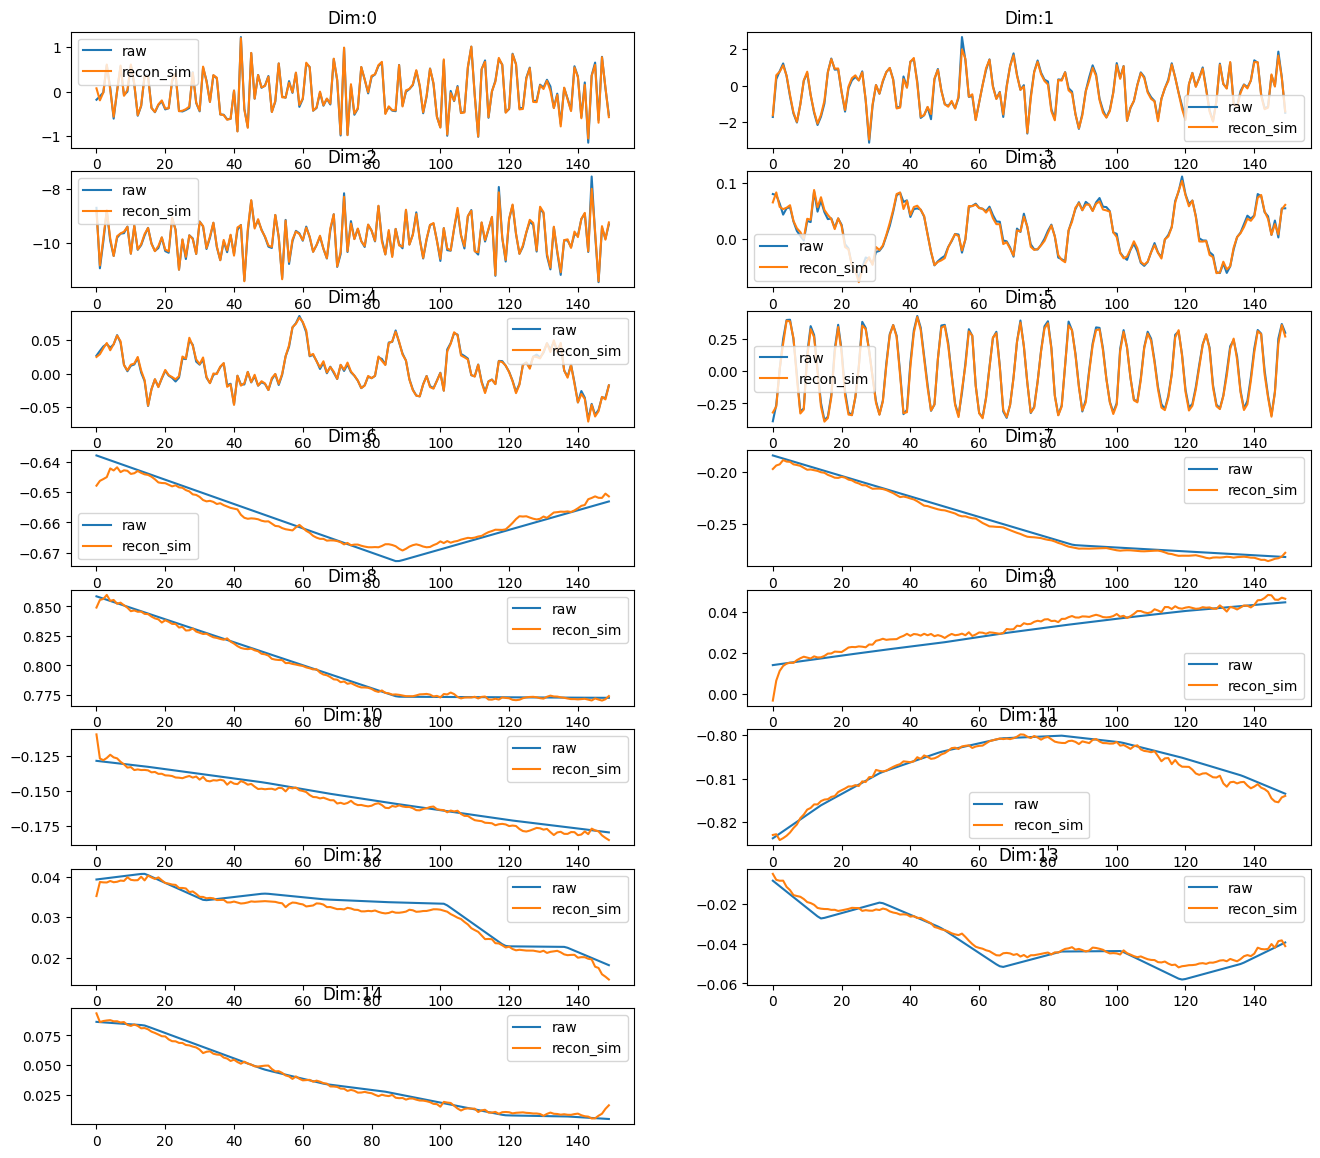

In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def plot_recon_data(plot_data=[takeoff_2_model_sim, takeoff_2_model_raw, takeoff_2_model_err], plot_batch=5, label=1, model=vae, is_norm=is_norm):
    _sim = plot_data[0][plot_batch]
    _raw = plot_data[1][plot_batch]
    _err = plot_data[2][plot_batch]

    err = _err.unsqueeze(0)
    modality = torch.tensor([label]).to(_err.dtype).unsqueeze(0)

    model.eval()
    recon_err, loss = vae(err.to(device))
    recon_err = recon_err.squeeze(0)
    recon_err = recon_err.cpu()

    if is_norm:
        raw_min_vals = label_ana[str(label)][0]
        raw_max_vals = label_ana[str(label)][1]
        sim_min_vals = label_ana[str(label)][2]
        sim_max_vals = label_ana[str(label)][3]
        err_min_vals = label_ana[str(label)][4]
        err_max_vals = label_ana[str(label)][5]

        _err = denormalize_data(_err, err_min_vals, err_max_vals)
        _sim = denormalize_data(_sim, sim_min_vals, sim_max_vals)
        _raw = denormalize_data(_raw, raw_min_vals, raw_max_vals)
        
        recon_x_denorm = denormalize_data(recon_err, err_min_vals, err_max_vals) 
        sim_recon_denorm = _sim - recon_x_denorm
    else:
        recon_x_denorm = recon_err
        sim_recon_denorm = _sim - recon_x_denorm
    
    _err = _err.detach().numpy()
    _sim = _sim.detach().numpy()
    _raw = _raw.detach().numpy()
    recon_x_denorm = recon_x_denorm.detach().numpy()
    sim_recon_denorm = sim_recon_denorm.detach().numpy()
    
    plt.figure(figsize=(16, 16))
    for i in range(input_dim):
        raw_data = _raw[:, i]
        sim_data = _sim[:, i]
        err_data = _err[:, i]
        recon_err_data = recon_x_denorm[:, i]
        sim_recon_data = sim_recon_denorm[:, i]
        plt.subplot(9, 2, i+1)
        plt.plot(raw_data, label='raw')
        plt.plot(sim_recon_data, label='recon_sim')
        # plt.plot(sim_recon_data, linestyle='--', label='recon')
        plt.title(f'Dim:{i}')
        plt.legend()
    
    rmse_list = []
    mae_list = []
    r2_list = []

    original_batch = _raw  
    reconstructed_batch = sim_recon_denorm  
    
    mse_batch = mean_squared_error(original_batch, reconstructed_batch)
    rmse_batch = np.sqrt(mse_batch)
    mae_batch = mean_absolute_error(original_batch, reconstructed_batch)
    r2_batch = r2_score(original_batch, reconstructed_batch)
    
    rmse_list.append(rmse_batch)
    mae_list.append(mae_batch)
    r2_list.append(r2_batch)

    avg_rmse = np.mean(rmse_list)
    avg_mae = np.mean(mae_list)
    avg_r2 = np.mean(r2_list)

    print(f"Reconstruction Errors (averaged over batches):")
    print(f"Average RMSE: {avg_rmse:.4f}")
    print(f"Average MAE: {avg_mae:.4f}")
    print(f"Average R²: {avg_r2:.4f}")

# plot_recon_data(plot_data=[takeoff_2_model_sim, takeoff_2_model_raw, takeoff_2_model_err], plot_batch=4, label=2, model=vae, is_norm=is_norm)
plot_recon_data(plot_data=[hover_2_model_sim, hover_2_model_raw, hover_2_model_err], plot_batch=1, label=1, model=vae, is_norm=is_norm)

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

vae.eval()  # 设置为评估模式，以防止 dropout 等训练专用的操作

reconstructions = []
originals = []

with torch.no_grad():
    for err, raw, sim, label in dataloader:
        err = err.to(device)
        label = label.to(device)
        recon_err, loss = vae(err)
        label = label.cpu()
        recon_err = recon_err.cpu()
        err = err.cpu()
        
        if is_norm:
            raw_min_vals = label_ana[str(label[0][0].numpy())][0]
            raw_max_vals = label_ana[str(label[0][0].numpy())][1]
            sim_min_vals = label_ana[str(label[0][0].numpy())][2]
            sim_max_vals = label_ana[str(label[0][0].numpy())][3]
            err_min_vals = label_ana[str(label[0][0].numpy())][4]
            err_max_vals = label_ana[str(label[0][0].numpy())][5]

            err_denorm = denormalize_data(err, err_min_vals, err_max_vals)
            recon_x_denorm = denormalize_data(recon_err, err_min_vals, err_max_vals) 

            raw_denorm = denormalize_data(raw, raw_min_vals, raw_max_vals)
            sim_denorm = denormalize_data(sim, sim_min_vals, sim_max_vals)

            sim_recon_denorm = sim_denorm - recon_x_denorm
        else:
            err_denorm = err
            recon_x_denorm = recon_err
            raw_denorm = raw
            sim_denorm = sim
            sim_recon_denorm = sim_denorm - recon_x_denorm

        # 存储原始数据和重构数据
        originals.append(raw_denorm.cpu())
        reconstructions.append(sim_recon_denorm.cpu())

reconstructed_data = torch.cat(reconstructions, dim=0)
original_data = torch.cat(originals, dim=0)

original_data_np = original_data.numpy()
reconstructed_data_np = reconstructed_data.numpy()

rmse_list = []
mae_list = []
r2_list = []

for i in range(original_data_np.shape[0]):
    original_batch = original_data_np[i]  # shape: (1000, 18)
    reconstructed_batch = reconstructed_data_np[i]  # shape: (1000, 18)
    
    mse_batch = mean_squared_error(original_batch, reconstructed_batch)
    rmse_batch = np.sqrt(mse_batch)
    mae_batch = mean_absolute_error(original_batch, reconstructed_batch)
    r2_batch = r2_score(original_batch, reconstructed_batch)
    
    rmse_list.append(rmse_batch)
    mae_list.append(mae_batch)
    r2_list.append(r2_batch)

# 计算所有 batch 的平均误差
avg_rmse = np.mean(rmse_list)
avg_mae = np.mean(mae_list)
avg_r2 = np.mean(r2_list)

print(f"Reconstruction Errors (averaged over batches):")
print(f"Average RMSE: {avg_rmse:.4f}")
print(f"Average MAE: {avg_mae:.4f}")
print(f"Average R²: {avg_r2:.4f}")


Reconstruction Errors (averaged over batches):
Average RMSE: 0.0594
Average MAE: 0.0222
Average R²: -3017.9423


In [11]:
import shutil

ReSaved = True

mode_name = 'autoFilter_vq_vae.pth'
folder_name = mode_name.split('.')[0]
folder_path = os.path.join(os.getcwd(), folder_name)
path = os.path.join(os.getcwd(), folder_name, mode_name)

if not os.path.exists(folder_path):
    os.makedirs(folder_path, exist_ok=True)

torch.save(vae, path)
print(f'Model Re-Saved to {path}')

Model Re-Saved to d:\Tjh\Platform\Enhanced-DT\model\compare\autoFilter_vq_vae\autoFilter_vq_vae.pth
